# Credit Card Default Prediction - Model Experiments

This notebook compares multiple classification models for predicting credit card default risk.

Models tested:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

The goal is to identify the best-performing model before converting the workflow into reusable production scripts.

### Imports and paths ###

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV
)

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
    )

In [5]:
from xgboost import XGBClassifier

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

In [7]:
from sklearn.inspection import permutation_importance

In [8]:
RANDOM_STATE = 999

In [9]:
DATA_PATH = Path("../data/processed/credit_default_cleaned.csv")
REPORT_DIR = Path("../reports")
MODEL_DIR = Path("../models")
IMAGE_DIR = Path("../reports/images")

In [10]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)

### Load cleaned dataset ###

In [11]:
df = pd.read_csv(DATA_PATH)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (30000, 24)


,credit_limit,sex,education,marriage,age,repayment_status_sep,repayment_status_aug,repayment_status_jul,repayment_status_jun,repayment_status_may,repayment_status_apr,bill_amount_sep,bill_amount_aug,bill_amount_jul,bill_amount_jun,bill_amount_may,bill_amount_apr,payment_amount_sep,payment_amount_aug,payment_amount_jul,payment_amount_jun,payment_amount_may,payment_amount_apr,default_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   credit_limit          30000 non-null  int64
 1   sex                   30000 non-null  int64
 2   education             30000 non-null  int64
 3   marriage              30000 non-null  int64
 4   age                   30000 non-null  int64
 5   repayment_status_sep  30000 non-null  int64
 6   repayment_status_aug  30000 non-null  int64
 7   repayment_status_jul  30000 non-null  int64
 8   repayment_status_jun  30000 non-null  int64
 9   repayment_status_may  30000 non-null  int64
 10  repayment_status_apr  30000 non-null  int64
 11  bill_amount_sep       30000 non-null  int64
 12  bill_amount_aug       30000 non-null  int64
 13  bill_amount_jul       30000 non-null  int64
 14  bill_amount_jun       30000 non-null  int64
 15  bill_amount_may       30000 non-null  int64
 16  bill

In [13]:
df['default_next_month'].value_counts(normalize=True) * 100

default_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64

### Split features and target ###

In [14]:
TARGET = 'default_next_month'
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (30000, 23)
y shape: (30000,)


### Train-test split ### 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state = RANDOM_STATE,
    stratify = y
)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

print('\ny_train distribusion:')
print(y_train.value_counts(normalize=True))

print('\ny_test distribution')
print(y_test.value_counts(normalize=True))

X_train: (22500, 23)
X_test: (7500, 23)

y_train distribusion:
default_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

y_test distribution
default_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


### CV and scoring setup ###

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = RANDOM_STATE)
scoring = {'accuracy' : 'accuracy',
           'precision' : 'precision',
           'recall' : 'recall',
           'f1' : 'f1',
           'roc_auc' : 'roc_auc'}

### Baseline models ###

In [17]:
models = {
    'Dummy Classifier': Pipeline(
        steps=[
            ('model', DummyClassifier(strategy='most_frequent'))
        ]
    ),

    'Logistic_Regression': Pipeline(
        steps=[
            ('scalar', StandardScaler()),
            ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
        ]
    ),

    'Decision_Tree': Pipeline(
        steps=[
            ('model', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
        ]
    ),

    'Random_Forest': Pipeline(
        steps=[
            ('model', RandomForestClassifier(n_estimators = 100, random_state = RANDOM_STATE, class_weight='balanced', n_jobs = -1))
        ]
    ),
    
    'Gradient_Boosting': Pipeline(
        steps=[
            ('model', GradientBoostingClassifier(random_state = RANDOM_STATE))
        ]
    ),

    'XGBoost' : Pipeline(
        steps=[
            ('model', XGBClassifier(
                n_estimators = 100,
                random_state = RANDOM_STATE,
                eval_metric = 'logloss',
                n_jobs = -1,
                colsample_bytree = 0.8,
                subsample = 0.8,
                max_depth = 3,
                learning_rate = 0.1
            ))
        ]
    )

}

### Cross-validation function ###

In [18]:
from sklearn.model_selection import cross_val_predict, cross_validate

cv_scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc' : 'roc_auc'    
}

def run_cross_validation(model_name, pipeline):
        """
    Run cross-validation for one model pipeline and return average validation metrics.

    Parameters
    ----------
    model_name : str
        Name of the model being evaluated.

    pipeline : sklearn Pipeline
        Model pipeline containing preprocessing steps and the estimator.

    Returns
    -------
    dict
        Mean cross-validation scores for accuracy, precision, recall, F1, and ROC-AUC.
    """

        scores = cross_validate(
                estimator = pipeline,
                X = X_train,
                y = y_train,
                cv = cv,
                scoring = cv_scoring,
                n_jobs = -1,
                return_train_score = True
        )

        return {
        "model": model_name,
        "train_accuracy": scores["train_accuracy"].mean(),
        "train_precision": scores["train_precision"].mean(),
        "train_recall": scores["train_recall"].mean(),
        "train_f1": scores["train_f1"].mean(),
        "train_roc_auc": scores["train_roc_auc"].mean(),
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_precision": scores["test_precision"].mean(),
        "cv_recall": scores["test_recall"].mean(),
        "cv_f1": scores["test_f1"].mean(),
        "cv_roc_auc": scores["test_roc_auc"].mean()
    }

In [19]:
cv_results = []
for model_name, pipeline in models.items():
    print(f"Running cross-validation for {model_name}...")
    result = run_cross_validation(model_name, pipeline)
    cv_results.append(result)

cv_results_df = pd.DataFrame(cv_results).sort_values(by='cv_f1', ascending=False)


Running cross-validation for Dummy Classifier...
Running cross-validation for Logistic_Regression...
Running cross-validation for Decision_Tree...
Running cross-validation for Random_Forest...
Running cross-validation for Gradient_Boosting...
Running cross-validation for XGBoost...


In [20]:
cv_results_df

,model,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
4,Gradient_Boosting,0.826811,0.696621,0.384519,0.495512,0.809493,0.819956,0.669441,0.367697,0.474566,0.777011
1,Logistic_Regression,0.681889,0.374431,0.652954,0.475927,0.726704,0.680533,0.372434,0.648793,0.473147,0.723695
5,XGBoost,0.825200,0.692374,0.377487,0.488588,0.808872,0.819911,0.672135,0.362875,0.471156,0.779906
3,Random_Forest,0.999422,0.997794,0.999598,0.998695,0.999981,0.811733,0.644497,0.332133,0.438245,0.759115
2,Decision_Tree,0.999378,0.997195,1.000000,0.998596,0.999999,0.728933,0.387528,0.388188,0.387787,0.607037
0,Dummy Classifier,0.778800,0.000000,0.000000,0.000000,0.500000,0.778800,0.000000,0.000000,0.000000,0.500000


### Baseline Cross-Validation Results

The baseline cross-validation results show that Gradient Boosting achieved the highest mean CV F1 score, followed closely by Logistic Regression and XGBoost. Accuracy alone is not a reliable metric for this problem because the Dummy Classifier achieved 77.88% accuracy by predicting only the majority class, but its F1 score and recall were 0.

Decision Tree and Random Forest showed strong signs of overfitting, with near-perfect training F1 scores but much lower validation F1 scores. Gradient Boosting and XGBoost generalised better, while Logistic Regression achieved the highest recall, meaning it caught more actual default customers but produced more false positives.

Based on these results, Gradient Boosting, XGBoost, and Logistic Regression are the strongest baseline candidates. Random Forest may still improve after hyperparameter tuning.

In [21]:
cv_results_df.to_csv(REPORT_DIR / 'cv_results_before_tuning.csv', index = False)

### Hyper parameter Tuning ###

In [22]:
param_grids = {
    'LogisticRegression': {
        'model__C': [0.1, 1, 10, 100],
        'model__solver': ['liblinear', 'lbfgs']
    },

    'Random_Forest':{
        'model__n_estimators': [100, 200, 300],
        'model__max_depth' : [4, 6, 8, 10, None],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 5, 10],
        'model__max_features': ['sqrt', 'log2', None]
    },

    'Gradient_Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.5, 0.1, 0.2],
        'model__max_depth': [2, 3, 5, 6, 10],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 5]
    },

        "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [23]:
# select only model we want to tune
models_to_tune = {
    "LogisticRegression": models["Logistic_Regression"],
    "Random_Forest": models["Random_Forest"],
    "Gradient_Boosting": models["Gradient_Boosting"],
    "XGBoost": models["XGBoost"]
}

### Create reusable tuning function ###

In [28]:
def tune_model(model_name, pipeline, param_grid, n_iter=20):
    """
    Tune hyperparameters for a given model pipeline using RandomizedSearchCV.

    Parameters
    ----------
    model_name : str
        Name of the model being tuned.

    pipeline : sklearn Pipeline
        Model pipeline containing preprocessing steps and the estimator.

    param_grid : dict
        Dictionary specifying the hyperparameter search space.

    n_iter : int, optional
        Number of parameter settings that are sampled. Default is 20.

    Returns
    -------
    dict
        Best hyperparameters and corresponding cross-validation scores.
    """
    
    print(f"Tuning hyperparameters for {model_name}... ")
    search = RandomizedSearchCV(
        estimator = pipeline,
        param_distributions = param_grid,
        n_iter = n_iter,
        scoring = 'f1',
        cv = cv,
        n_jobs = -1,
        random_state = RANDOM_STATE,
        verbose = 1,
        refit = True
    )

    search.fit(X_train, y_train)

    print(f"Best F1 for {model_name}: {search.best_score_:.4f}")
    print(f"Best hyperparameters for {model_name}: {search.best_params_}")    
    print("-" * 80)

    return {
        'model': model_name,
        'best_cv_f1': search.best_score_,
        'best_params': search.best_params_,
        'best_estimator': search.best_estimator_,
        'search_object': search
    }

### Running tuning for all selected models ###

In [39]:
tuning_results = []
for model_name, pipeline in models_to_tune.items():
    if model_name in ["Logistic_Regression", "LogisticRegression"]:
        n_iter = 10
    else:
        n_iter = 20  # Fewer iterations for Logistic Regression due to smaller hyperparameter space

    result = tune_model(
        model_name=model_name,
        pipeline = pipeline,
        param_grid = param_grids[model_name],
        n_iter = n_iter
    )
    tuning_results.append(result)

Tuning hyperparameters for LogisticRegression... 
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\srima\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best F1 for LogisticRegression: 0.4733
Best hyperparameters for LogisticRegression: {'model__solver': 'liblinear', 'model__C': 0.1}
--------------------------------------------------------------------------------
Tuning hyperparameters for Random_Forest... 
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best F1 for Random_Forest: 0.5432
Best hyperparameters for Random_Forest: {'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}
--------------------------------------------------------------------------------
Tuning hyperparameters for Gradient_Boosting... 
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best F1 for Gradient_Boosting: 0.4743
Best hyperparameters for Gradient_Boosting: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_depth': 3, 'model__learning_rate': 0.1}
-------------------

### Tuned model comparison table ###

In [41]:
clean_results = []

for result in tuning_results:
    clean_results.append({
        "model": result["model"],
        "best_cv_f1": result["best_cv_f1"],
        "best_params": result["best_params"]
    })

tuned_results_df = pd.DataFrame(clean_results).sort_values(
    by="best_cv_f1",
    ascending=False
)

tuned_results_df

,model,best_cv_f1,best_params
1,Random_Forest,0.543194,"{'model__n_estimators': 100, 'model__min_sampl..."
3,XGBoost,0.478071,"{'model__subsample': 0.8, 'model__n_estimators..."
2,Gradient_Boosting,0.474345,"{'model__subsample': 1.0, 'model__n_estimators..."
0,LogisticRegression,0.473335,"{'model__solver': 'liblinear', 'model__C': 0.1}"


### Saving Tuned Model ###

In [42]:
tuned_results_df.to_csv(REPORT_DIR / 'tuned_model_results.csv', index=False)

### Locking the best model ###

In [43]:
best_result = max(tuning_results,
                  key = lambda result: result['best_cv_f1'])
best_model_name = best_result['model']
best_model = best_result['best_estimator']
best_params = best_result['best_params']
best_cv_f1 = best_result['best_cv_f1']

print("Best tuned model:", best_model_name)
print("Best CV F1:", best_cv_f1)
print("Best parameters:")
print(best_params)

Best tuned model: Random_Forest
Best CV F1: 0.5431941868213382
Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}


### Evaluate on final test set ###

In [44]:
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

test_results = {
    "model": best_model_name,
    "test_accuracy": accuracy_score(y_test, y_test_pred),
    "test_precision": precision_score(y_test, y_test_pred),
    "test_recall": recall_score(y_test, y_test_pred),
    "test_f1": f1_score(y_test, y_test_pred),
    "test_roc_auc": roc_auc_score(y_test, y_test_proba)
}

test_results_df = pd.DataFrame([test_results])
test_results_df

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Random_Forest,0.7884,0.519231,0.585895,0.550552,0.784238


### Final Test Set Evaluation

The tuned Random Forest model was selected as the final model because it achieved the highest cross-validation F1 score after hyperparameter tuning. On the unseen test set, the model achieved an accuracy of 78.84%, precision of 51.92%, recall of 58.59%, F1-score of 55.06%, and ROC-AUC of 78.42%.

The test F1 score was slightly higher than the tuned cross-validation F1 score, suggesting that the model generalised well to unseen data. Compared with the Dummy Classifier baseline, the final model provides meaningful predictive value because it identifies a substantial proportion of actual default customers instead of only predicting the majority class.

In [45]:
test_results_df.to_csv(
    REPORT_DIR / 'test_results.csv', index=False
)

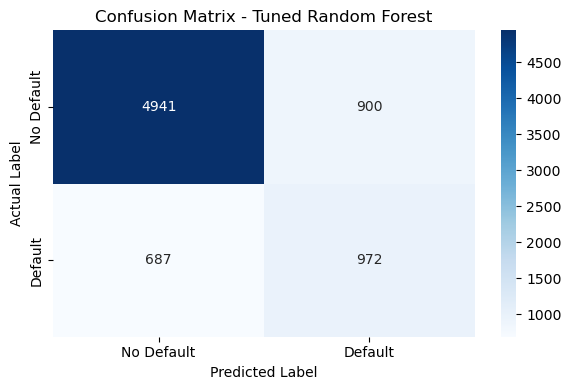

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.savefig(REPORT_DIR / "images" / "confusion_matrix.png", dpi=300)
plt.show()

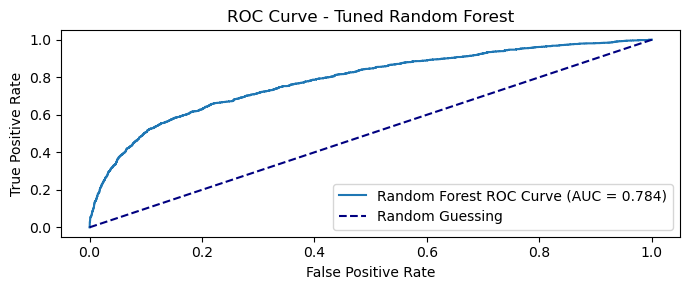

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(7,3))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    linestyle="--",
    label="Random Guessing"
)

plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(REPORT_DIR / "images" / "roc_curve.png", dpi=300)
plt.show()

### Saving final model with joblib ###

In [50]:
import joblib

joblib.dump(
    best_model,
    MODEL_DIR / "best_model.joblib"
)

['..\\models\\best_model.joblib']

In [51]:
loaded_model = joblib.load(MODEL_DIR / "best_model.joblib")
loaded_predictions = loaded_model.predict(X_test)
loaded_predictions[:10]

array([1, 1, 1, 0, 0, 1, 0, 0, 1, 0])

## Final Model Summary

After comparing multiple baseline models and tuning the strongest candidates using RandomizedSearchCV, the tuned Random Forest model was selected as the final model.

Random Forest achieved the highest tuned cross-validation F1 score of 0.5432. On the unseen test set, it achieved:

- Accuracy: 0.7884
- Precision: 0.5192
- Recall: 0.5859
- F1-score: 0.5506
- ROC-AUC: 0.7842

The model improved substantially over the Dummy Classifier baseline, which achieved 0 recall and 0 F1-score. This confirms that the final model provides meaningful predictive value for identifying customers at risk of default.